# 🔧 Adım 5 — Model Eğitimi & Optuna Hiperparametre Optimizasyonu

Her makine öğrenmesi modelinin **hiperparametreleri** vardır — eğitimden önce biz belirlememiz gereken ayarlar.  
Örneğin Random Forest için: kaç ağaç? Her ağaç ne kadar derin?

**Optuna** bu ayarları otomatik olarak arar:
- Her **trial** bir parametre kombinasyonu dener
- **TPE Sampler** geçmiş denemelerden öğrenerek daha iyi bölgeleri tahmin eder (kör arama değil)
- Hedef: **Macro-F1** skorunu maksimize et

> **Finansal analoji:** Grid search = tüm hisse kombinasyonlarını teker teker denemek.  
> Optuna/TPE = iyi getiri veren bölgelere odaklanarak akıllıca arama yapmak.

---
⚠️ **Bu notebook ~10-20 dakika sürebilir.** M4 tüm core'larını kullanacak.
---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
import os
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.metrics import f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from mrmr import mrmr_classif
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # sadece önemli mesajlar

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)
print('Kütüphaneler hazır ✓')

Kütüphaneler hazır ✓


In [4]:
# ── Tüm setup (önceki notebook'lardan) ──────────────────────────────────────
normal = pd.read_csv('../data/normal_radiomics.csv')
papil  = pd.read_csv('../data/papilodem_radiomics.csv')
normal['label'] = 0; papil['label'] = 1
df = pd.concat([normal, papil], ignore_index=True)
feature_cols = [c for c in df.columns if c.startswith('Feature_')]

def hasta_bazinda_bol(df, test_ratio=0.20, val_ratio=0.10, random_state=42):
    rng = np.random.RandomState(random_state)
    hasta_etiket = df.groupby('PatientIndex')['label'].first()
    train_idx, val_idx, test_idx = [], [], []
    for sinif in [0, 1]:
        hastalar = hasta_etiket[hasta_etiket == sinif].index.tolist()
        rng.shuffle(hastalar)
        n = len(hastalar)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        test_idx  += hastalar[:n_test]
        val_idx   += hastalar[n_test:n_test + n_val]
        train_idx += hastalar[n_test + n_val:]
    return (df[df['PatientIndex'].isin(train_idx)].copy(),
            df[df['PatientIndex'].isin(val_idx)].copy(),
            df[df['PatientIndex'].isin(test_idx)].copy())

class RadyomikOnIsleme:
    def __init__(self, variance_threshold=0.01, correlation_threshold=0.95):
        self.variance_threshold    = variance_threshold
        self.correlation_threshold = correlation_threshold
        self.imputer      = SimpleImputer(strategy='median')
        self.var_selector = VarianceThreshold(threshold=variance_threshold)
        self.scaler       = RobustScaler()
        self.selected_features_after_var  = None
        self.selected_features_after_corr = None

    def fit(self, X_train, feature_names):
        X_train = np.where(np.isinf(X_train), np.nan, X_train)
        X = self.imputer.fit_transform(X_train)
        self.var_selector.fit(X)
        mask_var = self.var_selector.get_support()
        self.selected_features_after_var = [f for f, m in zip(feature_names, mask_var) if m]
        X = X[:, mask_var]
        upper = pd.DataFrame(X, columns=self.selected_features_after_var).corr().abs().where(
            np.triu(np.ones((len(self.selected_features_after_var),)*2), k=1).astype(bool))
        drop = [col for col in upper.columns if any(upper[col] > self.correlation_threshold)]
        self.selected_features_after_corr = [f for f in self.selected_features_after_var if f not in drop]
        keep_idx = [self.selected_features_after_var.index(f) for f in self.selected_features_after_corr]
        self.scaler.fit(X[:, keep_idx])
        return self

    def transform(self, X, feature_names):
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.transform(X)
        X = pd.DataFrame(X, columns=feature_names)[self.selected_features_after_var].values
        X = pd.DataFrame(X, columns=self.selected_features_after_var)[self.selected_features_after_corr].values
        return self.scaler.transform(X)

    def fit_transform(self, X_train, feature_names):
        self.fit(X_train, feature_names)
        return self.transform(X_train, feature_names)

# MRMR k değeri
MRMR_K = 10
N_SPLITS = 20
N_TRIALS = 50  # Ödev minimum şartı

print('Setup hazır ✓')
print(f'MRMR k={MRMR_K}, {N_SPLITS} outer split, {N_TRIALS} Optuna trial/model')

Setup hazır ✓
MRMR k=10, 20 outer split, 50 Optuna trial/model


---
## Optuna Nasıl Çalışır?

```
for trial in range(N_TRIALS):
    1. TPE sampler → yeni parametre kombinasyonu öner
    2. Bu parametrelerle model oluştur
    3. StratifiedGroupKFold inner CV → Macro-F1 hesapla
    4. Skoru Optuna'ya bildir → bir sonraki trial için öğren
```

**StratifiedGroupKFold neden?**  
- **Stratified:** Her fold'da sınıf oranı korunur  
- **Group:** Aynı hastanın satırları aynı fold'da kalır (hasta bazında bölme)

**Inner CV neden?**  
Optuna'nın val setini "görmemesi" gerekir. Val seti threshold ve aggregation seçimi için ayrılmış durumda.  
Bu yüzden Optuna kendi iç döngüsünde train setini tekrar böler.

In [5]:
def hiperparametre_uzayi(trial, model_adi):
    """Her model için Optuna'nın arayacağı parametre aralıklarını tanımla."""
    if model_adi == 'RF':
        return RandomForestClassifier(
            n_estimators    = trial.suggest_int('n_estimators', 50, 500),
            max_depth       = trial.suggest_int('max_depth', 3, 20),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
            max_features    = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            random_state=42, n_jobs=-1  # M4: tüm core'lar
        )
    elif model_adi == 'ET':
        return ExtraTreesClassifier(
            n_estimators    = trial.suggest_int('n_estimators', 50, 500),
            max_depth       = trial.suggest_int('max_depth', 3, 20),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
            max_features    = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            random_state=42, n_jobs=-1
        )
    elif model_adi == 'GB':
        return GradientBoostingClassifier(
            n_estimators  = trial.suggest_int('n_estimators', 50, 300),
            max_depth     = trial.suggest_int('max_depth', 2, 8),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample     = trial.suggest_float('subsample', 0.5, 1.0),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
            random_state=42
        )

print('Hiperparametre uzayları tanımlandı ✓')
print('  RF : n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features')
print('  ET : aynı RF ile')
print('  GB : n_estimators, max_depth, learning_rate, subsample, min_samples_split')

Hiperparametre uzayları tanımlandı ✓
  RF : n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features
  ET : aynı RF ile
  GB : n_estimators, max_depth, learning_rate, subsample, min_samples_split


In [6]:
def optuna_calistir(X_train, y_train, groups, model_adi, n_trials=N_TRIALS):
    """
    Bir outer split'in train verisi üzerinde Optuna optimizasyonu.
    Inner CV: StratifiedGroupKFold (3-fold)
    """
    inner_cv = StratifiedGroupKFold(n_splits=3)

    def objective(trial):
        model = hiperparametre_uzayi(trial, model_adi)
        scores = []
        for train_idx, val_idx in inner_cv.split(X_train, y_train, groups):
            X_tr, X_va = X_train[train_idx], X_train[val_idx]
            y_tr, y_va = y_train[train_idx], y_train[val_idx]
            model.fit(X_tr, y_tr)
            scores.append(f1_score(y_va, model.predict(X_va), average='macro'))
        return np.mean(scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study

print('Optuna fonksiyonu hazır ✓')

Optuna fonksiyonu hazır ✓


---
## Ana Döngü — 20 Split × 3 Model

Her outer split için:
1. Train verisine ön işleme fit et
2. MRMR ile k=10 özellik seç (sadece train'de)
3. RF, ET, GB için ayrı ayrı Optuna çalıştır
4. En iyi parametrelerle full train'de yeniden eğit
5. Val seti sonuçlarını kaydet

⏱️ **Tahmini süre:** ~15-20 dk (M4, 50 trial × 3 model × 20 split)

In [7]:
import time
MODEL_ADLARI = ['RF', 'ET', 'GB']
tum_sonuclar = []
en_iyi_modeller = {}  # split_id → {model_adi: model}

baslangic = time.time()

for split_no in range(N_SPLITS):
    # ── Veri bölme ──────────────────────────────────────────────────────────
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no * 7 + 42)

    # ── Ön işleme (sadece train'e fit) ──────────────────────────────────────
    pipeline = RadyomikOnIsleme()
    X_train_proc = pipeline.fit_transform(train_df[feature_cols].values, feature_cols)
    X_val_proc   = pipeline.transform(val_df[feature_cols].values, feature_cols)
    y_train = train_df['label'].values
    y_val   = val_df['label'].values
    groups  = train_df['PatientIndex'].values  # inner CV için hasta grupları

    proc_cols = pipeline.selected_features_after_corr

    # ── MRMR (sadece train'de) ───────────────────────────────────────────────
    train_proc_df = pd.DataFrame(X_train_proc, columns=proc_cols)
    selected_feats = mrmr_classif(
        X=train_proc_df, y=pd.Series(y_train), K=MRMR_K
    )
    X_tr_mrmr = train_proc_df[selected_feats].values
    X_va_mrmr = pd.DataFrame(X_val_proc, columns=proc_cols)[selected_feats].values

    en_iyi_modeller[split_no] = {}

    for model_adi in MODEL_ADLARI:
        # ── Optuna ──────────────────────────────────────────────────────────
        study = optuna_calistir(X_tr_mrmr, y_train, groups, model_adi)

        # ── En iyi parametrelerle full train'de yeniden eğit ────────────────
        best_params = study.best_params
        model_final = hiperparametre_uzayi(
            optuna.trial.FixedTrial(best_params), model_adi
        )
        model_final.fit(X_tr_mrmr, y_train)
        en_iyi_modeller[split_no][model_adi] = model_final

        # ── Val seti değerlendirmesi ─────────────────────────────────────────
        y_pred_val = model_final.predict(X_va_mrmr)
        y_prob_val = model_final.predict_proba(X_va_mrmr)[:, 1]
        f1_val = f1_score(y_val, y_pred_val, average='macro')

        tum_sonuclar.append({
            'split'       : split_no,
            'model'       : model_adi,
            'val_macro_f1': round(f1_val, 4),
            'best_score'  : round(study.best_value, 4),
            'n_trials'    : len(study.trials)
        })

    gecen = time.time() - baslangic
    print(f'Split {split_no+1:2d}/20 tamamlandı ({gecen/60:.1f} dk)')

sonuc_df = pd.DataFrame(tum_sonuclar)
print(f'\n✓ Tüm split\'ler tamamlandı. Toplam süre: {(time.time()-baslangic)/60:.1f} dk')

100%|██████████| 10/10 [00:00<00:00, 69.55it/s]


Split  1/20 tamamlandı (1.0 dk)


100%|██████████| 10/10 [00:00<00:00, 71.19it/s]


Split  2/20 tamamlandı (1.9 dk)


100%|██████████| 10/10 [00:00<00:00, 71.85it/s]


...

Split 18/20 tamamlandı (18.1 dk)


100%|██████████| 10/10 [00:00<00:00, 70.16it/s]


Split 19/20 tamamlandı (19.1 dk)


100%|██████████| 10/10 [00:00<00:00, 72.07it/s]


Split 20/20 tamamlandı (19.9 dk)

✓ Tüm split'ler tamamlandı. Toplam süre: 19.9 dk


---
## Sonuçları İncele

=== 20 SPLIT VAL MACRO-F1 ÖZET ===


,Ortalama F1,Std,Min,Max
model,,,,
ET,0.8740,0.1540,0.4767,1.0
RF,0.8696,0.1452,0.4974,1.0
GB,0.8412,0.1404,0.4862,1.0


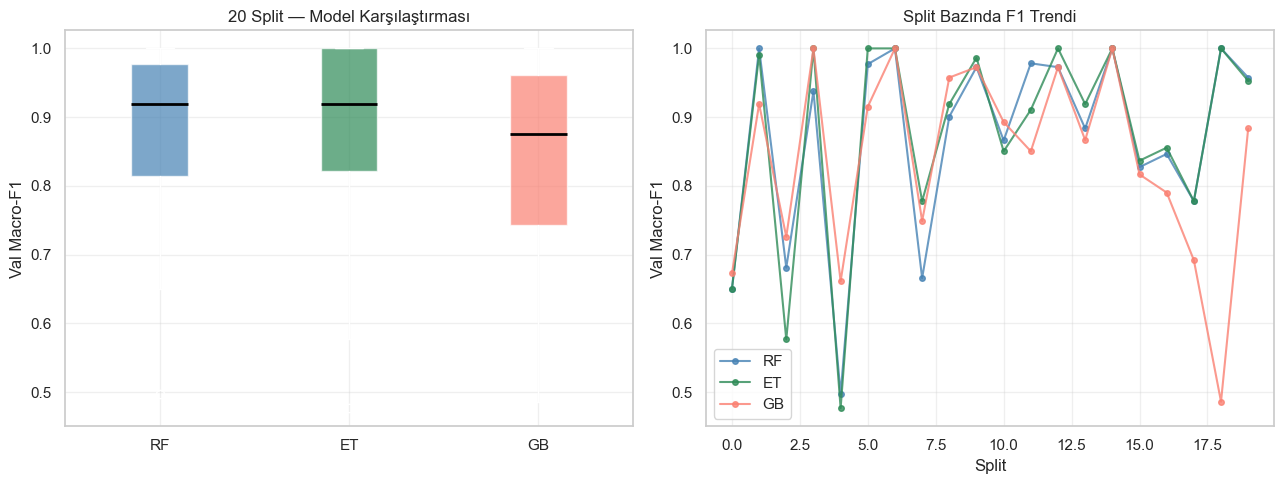

In [8]:
# Model bazında özet
ozet = sonuc_df.groupby('model')['val_macro_f1'].agg(['mean','std','min','max']).round(4)
ozet.columns = ['Ortalama F1', 'Std', 'Min', 'Max']
ozet = ozet.sort_values('Ortalama F1', ascending=False)
print('=== 20 SPLIT VAL MACRO-F1 ÖZET ===')
display(ozet)

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_renk = {'RF': 'steelblue', 'ET': 'seagreen', 'GB': 'salmon'}
veriler = [sonuc_df[sonuc_df.model == m]['val_macro_f1'].values for m in MODEL_ADLARI]
bp = axes[0].boxplot(veriler, labels=MODEL_ADLARI, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], MODEL_ADLARI):
    patch.set_facecolor(model_renk[m])
    patch.set_alpha(0.7)
axes[0].set_ylabel('Val Macro-F1')
axes[0].set_title('20 Split — Model Karşılaştırması')
axes[0].grid(True, alpha=0.3)

# Split bazında F1 trendi
for m in MODEL_ADLARI:
    alt = sonuc_df[sonuc_df.model == m]
    axes[1].plot(alt['split'], alt['val_macro_f1'],
                 marker='o', markersize=4, label=m,
                 color=model_renk[m], alpha=0.8)
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Val Macro-F1')
axes[1].set_title('Split Bazında F1 Trendi')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

Son split Optuna convergence grafiği çiziliyor...


100%|██████████| 10/10 [00:00<00:00, 67.11it/s]


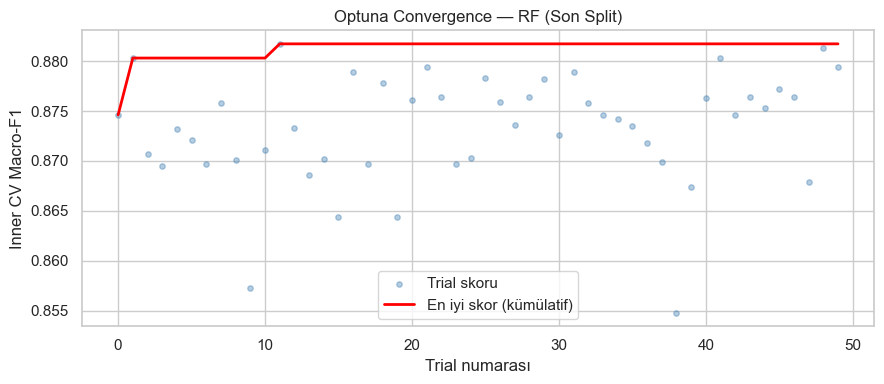

En iyi trial skoru: 0.8817
En iyi parametreler: {'n_estimators': 67, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'log2'}


In [9]:
# Optuna convergence — son split'te RF için trial süreci
# (Her split'te study objesi tutulmadı; bunu son split'te tekrar gösteriyoruz)
print('Son split Optuna convergence grafiği çiziliyor...')
train_df_last, val_df_last, _ = hasta_bazinda_bol(df, random_state=(N_SPLITS-1)*7+42)
pipeline_last = RadyomikOnIsleme()
X_tr_last = pipeline_last.fit_transform(train_df_last[feature_cols].values, feature_cols)
y_tr_last  = train_df_last['label'].values
g_last     = train_df_last['PatientIndex'].values
proc_last  = pipeline_last.selected_features_after_corr
feats_last = mrmr_classif(X=pd.DataFrame(X_tr_last, columns=proc_last),
                           y=pd.Series(y_tr_last), K=MRMR_K)
X_tr_m = pd.DataFrame(X_tr_last, columns=proc_last)[feats_last].values

study_vis = optuna_calistir(X_tr_m, y_tr_last, g_last, 'RF')

trial_vals = [t.value for t in study_vis.trials]
best_vals  = np.maximum.accumulate(trial_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(range(len(trial_vals)), trial_vals, alpha=0.4, s=15, color='steelblue', label='Trial skoru')
ax.plot(best_vals, color='red', linewidth=2, label='En iyi skor (kümülatif)')
ax.set_xlabel('Trial numarası')
ax.set_ylabel('Inner CV Macro-F1')
ax.set_title('Optuna Convergence — RF (Son Split)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig_optuna_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'En iyi trial skoru: {study_vis.best_value:.4f}')
print(f'En iyi parametreler: {study_vis.best_params}')

In [10]:
# Sonuçları kaydet
sonuc_df.to_csv('../results/optuna_val_sonuclari.csv', index=False)
print('Sonuçlar kaydedildi: results/optuna_val_sonuclari.csv')

print('\n=== ÖZET ===')
print(f'Toplam split    : {N_SPLITS}')
print(f'Toplam trial    : {N_TRIALS} / model / split')
print(f'Inner CV        : StratifiedGroupKFold (3-fold)')
en_iyi_model = ozet.index[0]
print(f'En iyi model    : {en_iyi_model} (Ort. F1: {ozet.loc[en_iyi_model, "Ortalama F1"]:.4f})')
print(f'\nSıradaki adım → 06_ensemble_kalibrasyon.ipynb')

Sonuçlar kaydedildi: results/optuna_val_sonuclari.csv

=== ÖZET ===
Toplam split    : 20
Toplam trial    : 50 / model / split
Inner CV        : StratifiedGroupKFold (3-fold)
En iyi model    : ET (Ort. F1: 0.8740)

Sıradaki adım → 06_ensemble_kalibrasyon.ipynb
